# 阶段 2.1：流场可视化系统

本 Notebook 完成：

1. 流线与等势线生成（psi=const, phi=const）

2. 驻点位置验证（Gamma=0 时应在 (±a,0)）

3. 流线闭合性验证（圆柱表面 10 点标准差阈值）

4. 网格无关性测试（101/201/301）

## 核心函数规范

- 命名：使用下划线格式（snake_case），例如 `calculate_velocity_field`。
- 注释：每个核心函数需说明“功能、输入、输出、物理参数”。
- 推荐模板：

```python
def complex_potential(z, U, a):
    """功能：计算圆柱绕流复势。

    输入：z(复数坐标), U(流速), a(半径)

    输出：复势值（复数）

    物理参数说明：U 为远场来流速度，a 为圆柱半径。
    """
    return U * (z + a**2 / z)
```

In [ ]:
import platform

import matplotlib

import numba

import numpy

import pandas

import PyQt5



print('Python :', platform.python_version())

print('numpy  :', numpy.__version__)

print('pandas :', pandas.__version__)

print('numba  :', numba.__version__)

print('matplotlib:', matplotlib.__version__)

print('PyQt5  :', PyQt5.QtCore.PYQT_VERSION_STR)


In [ ]:
from pathlib import Path

import sys


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise RuntimeError(
        "Cannot locate project root. Please open a folder inside flow_simulation_project."
    )


ROOT = find_project_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root detected.")

Project root detected.


Matplotlib is building the font cache; this may take a moment.


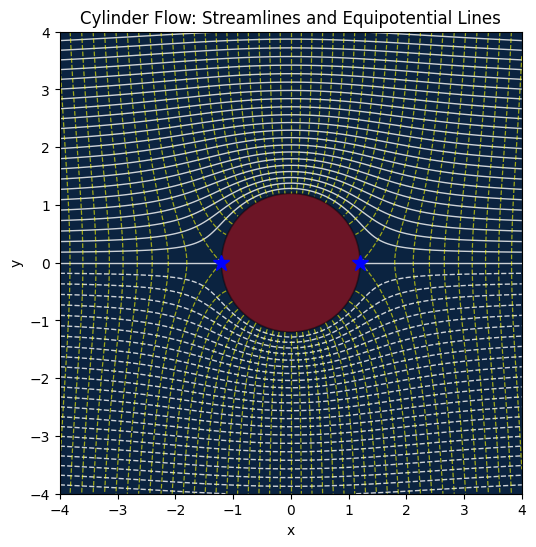

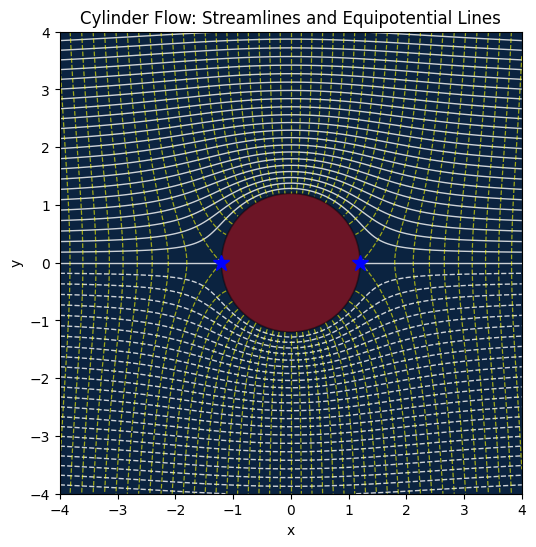

In [2]:
import numpy as np

from src import FlowSimulator

from src.visualization.plot_flow import plot_stream_and_potential



U = 3.0

a = 1.2

Gamma = 0.0



sim = FlowSimulator(U=U, a=a, gamma=Gamma, n=201, x_min=-4, x_max=4, y_min=-4, y_max=4)

res = sim.run()



fig, ax = plot_stream_and_potential(

    res['X'],

    res['Y'],

    res['phi'],

    res['psi'],

    a=a,

    stagnation=res['stagnation'],

    cp=res['cp'],

    u=res['u'],

    v=res['v'],

    show_potential=True,

    show_stagnation=True,

    show_pressure=False,

    show_quiver=False,

    levels=45,

)

fig


In [ ]:
# 速度云图（满足“速度箭头或速度云图”要求）
import matplotlib.pyplot as plt

speed = np.sqrt(res['u']**2 + res['v']**2)

fig_speed, ax_speed = plt.subplots(figsize=(7, 6))
pcm = ax_speed.contourf(res['X'], res['Y'], speed, levels=40, cmap='viridis')
ax_speed.contour(res['X'], res['Y'], res['psi'], levels=20, colors='white', linewidths=0.5, alpha=0.5)

cylinder = plt.Circle((0.0, 0.0), a, color='black', fill=False, linewidth=2.0)
ax_speed.add_patch(cylinder)

ax_speed.plot([-a, a], [0, 0], 'ro', ms=6, label='驻点 $(\pm a,0)$')
ax_speed.set_aspect('equal', adjustable='box')
ax_speed.set_title('速度云图 + 流线 + 圆柱/驻点标记')
ax_speed.set_xlabel('x')
ax_speed.set_ylabel('y')
ax_speed.legend(loc='upper right')
fig_speed.colorbar(pcm, ax=ax_speed, label='|V|')

fig_speed.savefig('../reports/figures/stage2_velocity_contour.png', dpi=220, bbox_inches='tight')
fig_speed

In [3]:
# 物理验证 1：流线闭合性（圆柱表面 10 点）

boundary_std = sim.boundary_streamline_std(n_points=10)

threshold = 0.01 * U * a



# 物理验证 2：驻点位置（Gamma=0）

stag = np.sort(np.real(res['stagnation']))

stag_err = max(abs(stag[0] + a), abs(stag[1] - a))

stag_tol = 0.01 * a



print(f"boundary std = {boundary_std:.6e}, threshold = {threshold:.6e}")

print(f"stagnation error = {stag_err:.6e}, tolerance = {stag_tol:.6e}")



# 网格无关性测试

def sample_streamline_metric(n):

    s = FlowSimulator(U=U, a=a, gamma=Gamma, n=n, x_min=-4, x_max=4, y_min=-4, y_max=4)

    r = s.run()

    # 使用外域流函数均值作为简单稳定性指标

    mask = np.sqrt(r['X']**2 + r['Y']**2) > 1.3 * a

    return np.nanmean(r['psi'][mask])



m101 = sample_streamline_metric(101)

m201 = sample_streamline_metric(201)

m301 = sample_streamline_metric(301)



print('grid metric 101/201/301 =', m101, m201, m301)

print('delta(201-101)=', abs(m201 - m101))

print('delta(301-201)=', abs(m301 - m201))



fig.savefig('../reports/figures/stage2_flow_lines.png', dpi=220, bbox_inches='tight')


boundary std = 0.000000e+00, threshold = 3.600000e-02
stagnation error = 2.220446e-16, tolerance = 1.200000e-02
grid metric 101/201/301 = 4.042198674546348e-16 0.00012375020923959974 1.093306929253708e-15
delta(201-101)= 0.00012375020923919552
delta(301-201)= 0.00012375020923850643
